In [1]:
# Install and Imports
!pip install torch matplotlib -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
import math
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Load dataset( Tiny Shakespeare)
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)

# Train/val split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]


In [13]:
# Hyperparameters
block_size = 64
batch_size = 32
d_model = 128
n_heads = 4
n_layers = 2
d_ff = 4 * d_model
lr = 3e-4
steps = 500


In [14]:
# Dataloader

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [15]:
# Swiglu FFN
class SwiGLU(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_model, d_ff)
        self.w3 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.w3(F.silu(self.w1(x)) * self.w2(x))

In [16]:
# Gelu FFN
class GELU_FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


In [17]:
# Transformer block
class Block(nn.Module):
    def __init__(self, use_swiglu=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)

        if use_swiglu:
            self.ffn = SwiGLU(d_model, d_ff)
        else:
            self.ffn = GELU_FFN(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(self.ln1(x), self.ln1(x), self.ln1(x))[0]
        x = x + self.ffn(self.ln2(x))
        return x


In [18]:
# GPT Model
class GPT(nn.Module):
    def __init__(self, use_swiglu=False):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(*[
            Block(use_swiglu) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        B, T = x.shape
        tok = self.token_emb(x)
        pos = self.pos_emb(torch.arange(T, device=device))

        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, vocab_size),
                targets.view(-1)
            )

        return logits, loss

In [19]:
# Training function
def train_model(use_swiglu=False):
    model = GPT(use_swiglu).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    losses = []

    for step in range(steps):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if step % 50 == 0:
            print(f"{'SwiGLU' if use_swiglu else 'GELU'} | Step {step} | Loss {loss.item():.4f}")

    return losses


In [20]:
# Train both models

gelu_losses = train_model(use_swiglu=False)
swiglu_losses = train_model(use_swiglu=True)

GELU | Step 0 | Loss 4.2999
GELU | Step 50 | Loss 2.9619
GELU | Step 100 | Loss 2.6880
GELU | Step 150 | Loss 2.6172
GELU | Step 200 | Loss 2.4505
GELU | Step 250 | Loss 1.6352
GELU | Step 300 | Loss 0.6536
GELU | Step 350 | Loss 0.3095
GELU | Step 400 | Loss 0.1900
GELU | Step 450 | Loss 0.1220
SwiGLU | Step 0 | Loss 4.3415
SwiGLU | Step 50 | Loss 2.9903
SwiGLU | Step 100 | Loss 2.6346
SwiGLU | Step 150 | Loss 2.5852
SwiGLU | Step 200 | Loss 2.4839
SwiGLU | Step 250 | Loss 2.3934
SwiGLU | Step 300 | Loss 1.6563
SwiGLU | Step 350 | Loss 0.4642
SwiGLU | Step 400 | Loss 0.2182
SwiGLU | Step 450 | Loss 0.1131


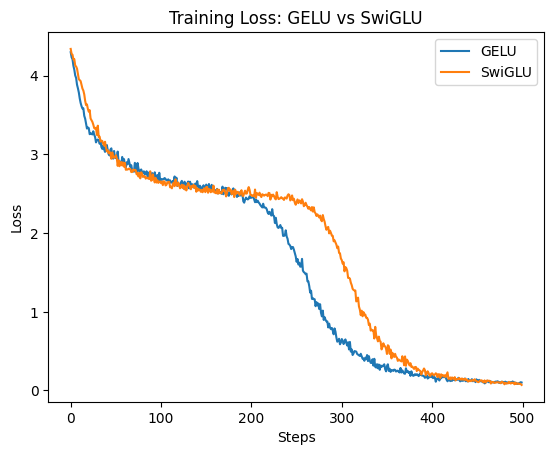

In [21]:
# Plot comparisson

plt.plot(gelu_losses, label="GELU")
plt.plot(swiglu_losses, label="SwiGLU")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss: GELU vs SwiGLU")
plt.legend()
plt.show()

In [ ]:
'''Conclusion

Both GELU and SwiGLU reduce loss over time, so both are working correctly.
GELU learns faster in the beginning (its loss drops earlier).
SwiGLU is slower at first but improves strongly later.
In the end, SwiGLU slightly beats GELU, so it learns better overall.'''